# Training a Behler-Parrinello potential from scratch

This tutorial walks the whole descpot pipeline on a deliberately small dataset:
generate BCC TiZrNb structures, label them with the surrogate teacher, split
leakage-safely by generation group, train the from-scratch BPNN, and measure the
final held-out error.

Two things to keep in mind:

- **Labels are surrogate model labels.** The teacher is CHGNet, a pretrained
  universal potential trained on DFT data. Nothing here is a DFT calculation.
- **This is a miniature.** A few hundred frames, three compositions, short
  training. The committed benchmark numbers in `results/metrics.json` come from
  the full suite (`scripts/run_all.py`), not from this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from descpot.structures import bcc_supercell, rattle_batch, strain_batch
from descpot.data import group_split
from descpot.descriptors import AcsfParams, build_graph, compute_descriptors
from descpot.training import TrainSettings, make_bpnn, train_potential, prepare_batches, evaluate_batches

np.random.seed(0)
torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110

## 1. Generate structures

BCC supercells with random site occupancy, rattled at two amplitudes plus a
strained batch, for three compositions. Every batch is one *generation group*;
that id is what the split will respect later.

192 frames, 18 generation groups


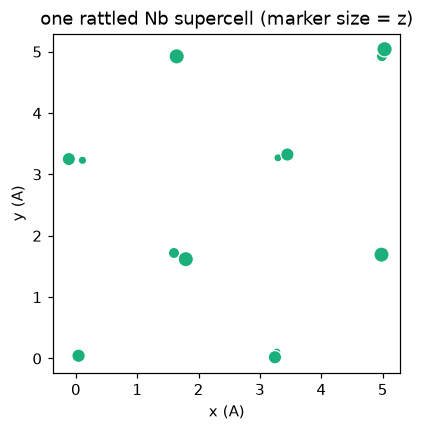

In [2]:
compositions = ["Nb", "TiNb", "TiZrNb"]
frames = []
for ci, comp in enumerate(compositions):
    for b, amp in enumerate([0.06, 0.14]):
        for rep in range(2):  # two batches per amplitude -> enough groups that
            # the group split keeps every composition in training
            frames.extend(rattle_batch(comp, reps=2, amplitude=amp, n_frames=12,
                                       seed=100 + 20 * ci + 10 * b + rep, batch=2 * b + rep))
    frames.extend(strain_batch(comp, reps=2, n_frames=16, seed=200 + ci, batch=0))
print(f"{len(frames)} frames, {len({fr.group for fr in frames})} generation groups")

fr = frames[0]
fig, ax = plt.subplots(figsize=(4.2, 4.0))
colors = np.array(["#2a78d6", "#eb6834", "#1baf7a"])  # Ti, Zr, Nb
ax.scatter(fr.positions[:, 0], fr.positions[:, 1], s=fr.positions[:, 2] * 14 + 30,
           c=colors[fr.species], edgecolors="white", linewidths=0.8)
ax.set_xlabel("x (A)"); ax.set_ylabel("y (A)")
ax.set_title(f"one rattled {fr.composition} supercell (marker size = z)")
ax.set_aspect("equal"); plt.show()

## 2. Label with the surrogate teacher

CHGNet provides energies and forces. On CPU this is the slowest cell (about a
minute); real projects batch this offline.

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cpu
CHGNet will run on cpu


H:\pv\descpot\Lib\site-packages\chgnet\model\model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)


teacher: chgnet 0.4.2 (CHGNet v0.3.0 (default pretrained weights, MPtrj-trained))
labeled 192 frames at 0.087 s/frame


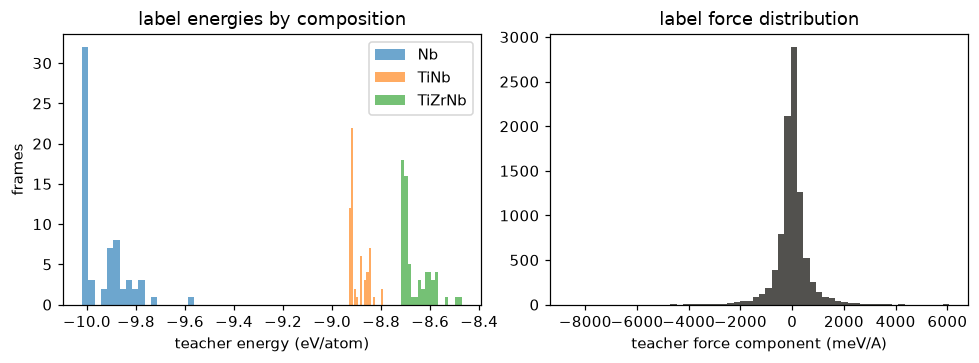

In [3]:
from descpot.teacher import get_teacher, label_frames

calc, teacher_info = get_teacher("chgnet")
seconds_per_frame = label_frames(frames, calc)
print(f"teacher: {teacher_info['package']} {teacher_info['version']} ({teacher_info['checkpoint']})")
print(f"labeled {len(frames)} frames at {seconds_per_frame:.3f} s/frame")

energies = np.array([f.energy / f.n_atoms for f in frames])
comps = np.array([f.composition for f in frames])
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for comp in compositions:
    axes[0].hist(energies[comps == comp], bins=18, alpha=0.65, label=comp)
axes[0].set_xlabel("teacher energy (eV/atom)"); axes[0].set_ylabel("frames"); axes[0].legend()
axes[0].set_title("label energies by composition")
all_forces = np.concatenate([f.forces.ravel() for f in frames])
axes[1].hist(all_forces * 1000, bins=60, color="#52514e")
axes[1].set_xlabel("teacher force component (meV/A)"); axes[1].set_title("label force distribution")
plt.tight_layout(); plt.show()

## 3. Descriptors

Atom-centered symmetry functions: 24 element-resolved radial G2 features and 24
element-pair-resolved angular G4 features per atom, all differentiable in
PyTorch so forces come from autograd.

descriptor matrix for 24 frames: (384, 48) (atoms x features)


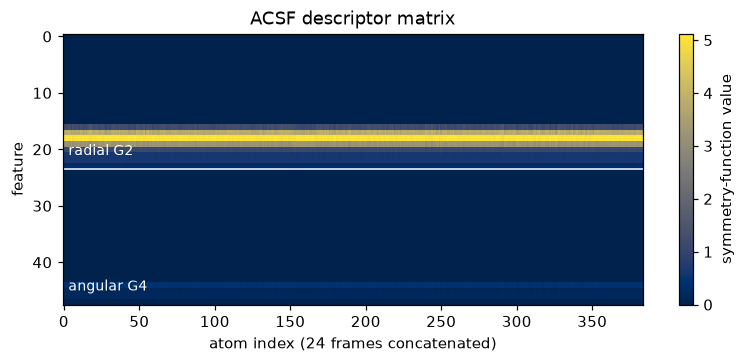

In [4]:
acsf = AcsfParams()
graph = build_graph(frames[:24], acsf)
desc = compute_descriptors(graph.positions, graph, acsf)
print(f"descriptor matrix for 24 frames: {tuple(desc.shape)} (atoms x features)")

fig, ax = plt.subplots(figsize=(8.5, 3.2))
im = ax.imshow(desc.numpy().T, aspect="auto", cmap="cividis", interpolation="nearest")
ax.axhline(23.5, color="white", lw=1.0)
ax.set_xlabel("atom index (24 frames concatenated)")
ax.set_ylabel("feature")
ax.text(3, 21, "radial G2", color="white", fontsize=9)
ax.text(3, 45, "angular G4", color="white", fontsize=9)
fig.colorbar(im, label="symmetry-function value")
ax.set_title("ACSF descriptor matrix")
plt.show()

## 4. Split by generation group

Sibling frames from one rattle or strain batch are near-duplicates. A random
frame split would put some of each batch on both sides and overstate accuracy;
the group split keeps every batch intact.

{'train': 112, 'val': 40, 'test': 40}
held-out groups: ['Nb_strain_shear_b0', 'Nb_strain_vol_b0', 'TiNb_rattle06_b1', 'TiZrNb_rattle14_b2']
train compositions: ['Nb', 'TiNb', 'TiZrNb']


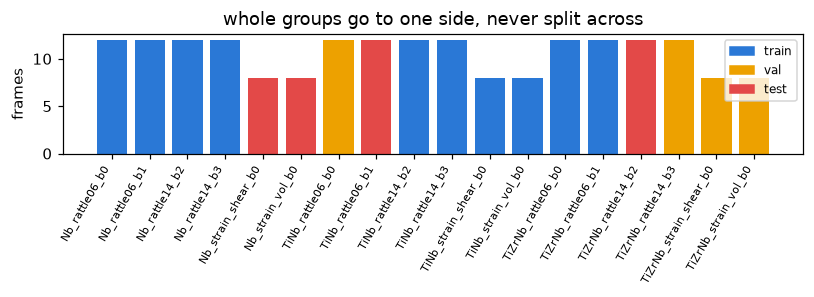

In [5]:
split = group_split(frames, holdout_compositions=(), val_fraction=0.15, test_fraction=0.2, seed=0)
parts = {"train": split.train, "val": split.val, "test": split.test}
print({k: len(v) for k, v in parts.items()})
test_groups = sorted({frames[i].group for i in split.test})
print("held-out groups:", test_groups)
print("train compositions:", sorted({frames[i].composition for i in split.train}))
# every composition must appear in training, or the per-element reference
# energies would be underdetermined (descpot warns if that happens)

fig, ax = plt.subplots(figsize=(7.5, 2.8))
groups = sorted({fr.group for fr in frames})
part_of_group = ["test" if g in test_groups else ("val" if g in {frames[i].group for i in split.val} else "train") for g in groups]
color_map = {"train": "#2a78d6", "val": "#eda100", "test": "#e34948"}
sizes = [sum(1 for fr in frames if fr.group == g) for g in groups]
ax.bar(range(len(groups)), sizes, color=[color_map[p] for p in part_of_group])
ax.set_xticks(range(len(groups)), groups, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("frames")
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[p]) for p in ("train", "val", "test")]
ax.legend(handles, ["train", "val", "test"], fontsize=8)
ax.set_title("whole groups go to one side, never split across")
plt.tight_layout(); plt.show()

## 5. Train the BPNN

Per-element networks on standardized descriptors, weighted energy-plus-force
loss, Adam with cosine decay. A short budget is enough for the miniature.

7971 parameters, 10 s, best epoch 29


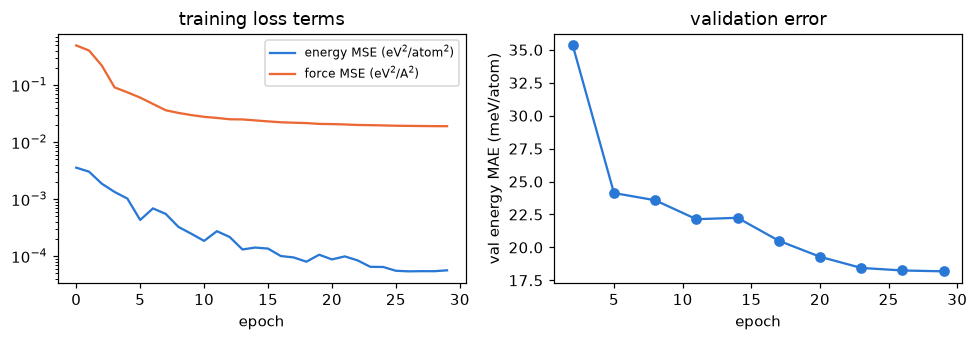

In [6]:
settings = TrainSettings(epochs=30, batch_size=16, lr=3e-3, force_weight=0.1, val_every=3, seed=0)
model = make_bpnn(acsf, hidden=(32, 32), seed=0)
history = train_potential(model, frames, split.train, split.val, settings)
print(f"{history['n_parameters']} parameters, {history['train_seconds']:.0f} s, best epoch {history['best_epoch']}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].semilogy(history["epoch"], history["loss_e"], color="#2a78d6", label="energy MSE (eV$^2$/atom$^2$)")
axes[0].semilogy(history["epoch"], history["loss_f"], color="#eb6834", label="force MSE (eV$^2$/A$^2$)")
axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8); axes[0].set_title("training loss terms")
val = history["val"]
axes[1].plot([v["epoch"] for v in val], [v["e_mae_mev_per_atom"] for v in val], "o-", color="#2a78d6")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val energy MAE (meV/atom)")
axes[1].set_title("validation error")
plt.tight_layout(); plt.show()

## 6. Final metric on held-out groups

Energy and force parity on batches the model never saw during training or
validation.

held-out energy MAE: 45.7 meV/atom
held-out force MAE:  88 meV/A


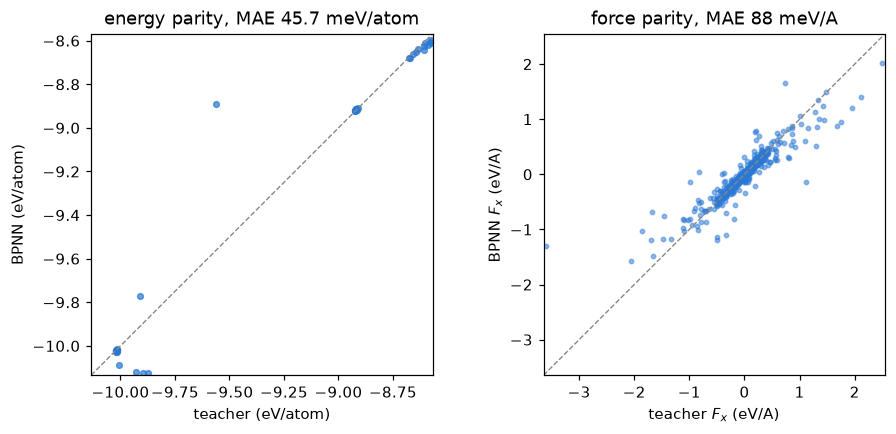

In [7]:
test_batches = prepare_batches(frames, split.test, acsf, settings.batch_size, seed=99)
metrics = evaluate_batches(model, test_batches)
print(f"held-out energy MAE: {metrics['e_mae_mev_per_atom']:.1f} meV/atom")
print(f"held-out force MAE:  {metrics['f_mae_mev_per_a']:.0f} meV/A")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.0))
et, ep = np.array(metrics["e_true_per_atom"]), np.array(metrics["e_pred_per_atom"])
lims = (min(et.min(), ep.min()) - 0.01, max(et.max(), ep.max()) + 0.01)
axes[0].plot(lims, lims, "--", color="#898781", lw=0.9)
axes[0].scatter(et, ep, s=14, color="#2a78d6", alpha=0.7)
axes[0].set_xlim(lims); axes[0].set_ylim(lims); axes[0].set_aspect("equal")
axes[0].set_xlabel("teacher (eV/atom)"); axes[0].set_ylabel("BPNN (eV/atom)")
axes[0].set_title(f"energy parity, MAE {metrics['e_mae_mev_per_atom']:.1f} meV/atom")
ft, fp = np.array(metrics["f_true_sample"]), np.array(metrics["f_pred_sample"])
lims = (min(ft.min(), fp.min()) - 0.05, max(ft.max(), fp.max()) + 0.05)
axes[1].plot(lims, lims, "--", color="#898781", lw=0.9)
axes[1].scatter(ft, fp, s=8, color="#2a78d6", alpha=0.5)
axes[1].set_xlim(lims); axes[1].set_ylim(lims); axes[1].set_aspect("equal")
axes[1].set_xlabel("teacher $F_x$ (eV/A)"); axes[1].set_ylabel("BPNN $F_x$ (eV/A)")
axes[1].set_title(f"force parity, MAE {metrics['f_mae_mev_per_a']:.0f} meV/A")
plt.tight_layout(); plt.show()

## Where to go next

- `scripts/run_all.py` reproduces the full benchmark (about an hour on CPU).
- `results/metrics.json` and `RESULTS.md` hold the committed full-scale numbers.
- The `descpot` CLI runs prediction, EOS scans, and NVE checks against the
  committed checkpoints in `models/`.
